# 📊 Analyse des ventes – Dashboard interactif

## Objectif
Ce projet a pour objectif d’analyser les performances des ventes par région et par catégorie à partir du dataset Superstore.

## Problématique métier
Une entreprise souhaite suivre ses ventes, ses profits et ses marges afin d’identifier les zones les plus performantes et celles à améliorer.

## Outils utilisés
- Excel / LibreOffice Calc
- Python
- Pandas
- Matplotlib

## Résultats attendus
- Calcul des KPI principaux
- Analyse des ventes par région
- Analyse des ventes par catégorie
- Création d’un dashboard interactif

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Chargement des données
Nous importons le dataset Superstore pour explorer sa structure et vérifier la qualité des données.

In [4]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Vérification de la qualité des données
Nous vérifions les valeurs manquantes et les types de variables avant de calculer les indicateurs clés.


In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")

## Calcul des KPI
Nous calculons les indicateurs principaux :
- ventes totales
- profit total
- marge globale

In [12]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
global_margin = total_profit / total_sales

print("Total des ventes :", round(total_sales, 2))
print("Total du profit :", round(total_profit, 2))
print("Marge globale :", round(global_margin * 100, 2), "%")

Total des ventes : 2297200.86
Total du profit : 286397.02
Marge globale : 12.47 %


## Analyse des ventes par région
Cette étape permet d’identifier les régions les plus performantes.

In [13]:
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
sales_by_region

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [14]:
profit_by_region = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
profit_by_region

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [15]:
margin_by_region = (df.groupby("Region")["Profit"].sum() / df.groupby("Region")["Sales"].sum()).sort_values(ascending=False)
margin_by_region

Region
West       0.149448
East       0.134834
South      0.119343
Central    0.079216
dtype: float64

## Analyse des ventes par catégorie
Nous observons les catégories qui génèrent le plus de chiffre d’affaires.

In [17]:
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
sales_by_category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [18]:
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
profit_by_category

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

## Visualisations
Les graphiques ci-dessous permettent de visualiser les performances par région et par catégorie.

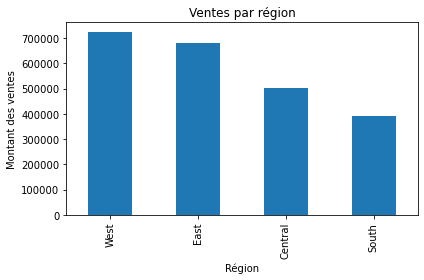

In [19]:
sales_by_region.plot(kind="bar")
plt.title("Ventes par région")
plt.xlabel("Région")
plt.ylabel("Montant des ventes")
plt.tight_layout()
plt.show()

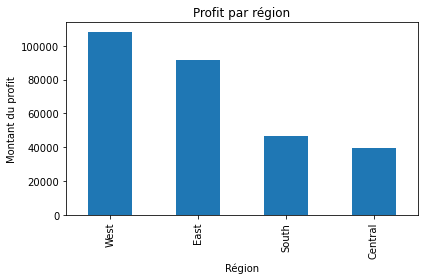

In [20]:
profit_by_region.plot(kind="bar")
plt.title("Profit par région")
plt.xlabel("Région")
plt.ylabel("Montant du profit")
plt.tight_layout()
plt.show()

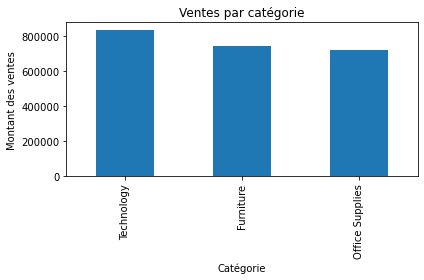

In [21]:
sales_by_category.plot(kind="bar")
plt.title("Ventes par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Montant des ventes")
plt.tight_layout()
plt.show()

## Aperçu du dashboard

![Dashboard](dashboard.PNG)

## Conclusion

Cette analyse met en évidence les différences de performance entre les régions et les catégories de produits.

Les KPI calculés et les visualisations obtenues ont servi de base à la création d’un dashboard interactif dans Excel / LibreOffice Calc.

### Points clés
- identification des régions les plus performantes
- comparaison des profits par zone
- suivi des ventes par catégorie
- aide à la prise de décision grâce à une visualisation synthétique